# Task 1 – Exploratory Data Analysis
## AlphaCare Insurance Solutions (ACIS) – Car Insurance Risk Analytics

**Analyst:** Marketing Analytics Engineer  
**Period covered:** February 2014 – August 2015  
**Objective:** Build a foundational understanding of the data, assess quality, and uncover initial risk and profitability patterns.

---

### Two key derived metrics anchor this analysis:

| Metric | Formula |
|--------|--------|
| **Loss Ratio** | `TotalClaims / TotalPremium` |
| **Margin** | `TotalPremium − TotalClaims` |

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from data_loader import load_raw_data, coerce_types, assess_missing, handle_missing, engineer_features
from eda_utils import (
    numeric_summary, categorical_summary,
    plot_numeric_distributions, plot_categorical_distributions,
    plot_premium_vs_claims, plot_correlation_matrix,
    plot_loss_ratio_by_province, plot_geographic_premium_heatmap,
    plot_boxplots, plot_loss_ratio_by_vehicle_type,
    plot_monthly_claim_trends, plot_top_makes_by_claims, plot_gender_loss_ratio,
)

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Data Loading

In [2]:
RAW_PATH = '../data/raw/MachineLearningRating_v3.txt'

df_raw = load_raw_data(RAW_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Shape: 1,000,098 rows × 52 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.000,"2,597.000",130.000,S/D,4.000,6/2002,"119,300.000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.010,Monthly,25.000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.930,0.000
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.000,"2,597.000",130.000,S/D,4.000,6/2002,"119,300.000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.010,Monthly,25.000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.930,0.000
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.000,"2,597.000",130.000,S/D,4.000,6/2002,"119,300.000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.010,Monthly,25.000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000,0.000


## 2. Data Summarisation – dtypes & Schema

In [3]:
print('Column dtypes:\n')
print(df_raw.dtypes.to_string())

Column dtypes:

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfDoor

In [4]:
# Coerce types
df = coerce_types(df_raw)
print('After type coercion:')
print(df.dtypes.to_string())

After type coercion:
UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                   category
Citizenship                       category
LegalType                         category
Title                             category
Language                          category
Bank                              category
AccountType                       category
MaritalStatus                     category
Gender                            category
Country                           category
Province                          category
PostalCode                             str
MainCrestaZone                    category
SubCrestaZone                     category
ItemType                          category
mmcode                             float64
VehicleType                       category
RegistrationYear                     int64
make                              category
Model                            

### Descriptive statistics – numeric features

In [5]:
num_summary = numeric_summary(df)
print('Numeric feature summary:')
num_summary

Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing_pct
UnderwrittenCoverID,"1,000,098.000","104,817.546","63,293.708",1.000,"55,143.000","94,083.000","139,190.000","301,175.000",0.612,0.029,0.000
PolicyID,"1,000,098.000","7,956.682","5,290.039",14.000,"4,500.000","7,071.000","11,077.000","23,246.000",0.737,0.282,0.000
mmcode,"999,546.000","54,877,704.020","13,603,805.344","4,041,200.000","60,056,925.000","60,058,415.000","60,058,418.000","65,065,350.000",-2.609,5.616,0.060
RegistrationYear,"1,000,098.000","2,010.225",3.261,"1,987.000","2,008.000","2,011.000","2,013.000","2,015.000",-0.794,0.608,0.000
Cylinders,"999,546.000",4.047,0.294,0.000,4.000,4.000,4.000,10.000,5.705,71.285,0.060
cubiccapacity,"999,546.000","2,466.743",442.801,0.000,"2,237.000","2,694.000","2,694.000","12,880.000",3.576,102.290,0.060
kilowatts,"999,546.000",97.208,19.393,0.000,75.000,111.000,111.000,309.000,0.245,3.010,0.060
NumberOfDoors,"999,546.000",4.019,0.468,0.000,4.000,4.000,4.000,6.000,-2.531,18.834,0.060
CustomValueEstimate,"220,456.000","225,531.130","564,515.750","20,000.000","135,000.000","220,000.000","280,000.000","26,550,000.000",40.871,"1,762.322",77.960
CapitalOutstanding,"999,776.000","52,605.221","111,417.191",-2.000,0.000,0.000,0.000,"700,000.000",2.015,3.265,0.030


### Descriptive statistics – categorical features

In [6]:
cat_summary = categorical_summary(df)
print('Categorical feature summary:')
cat_summary

Categorical feature summary:


,n_unique,top_value,top_freq_pct,missing_pct
column,,,,
IsVATRegistered,2,False,99.500,0.000
Citizenship,3,ZA,10.370,89.510
LegalType,6,Individual,91.180,0.000
Title,5,Mr,93.350,0.000
Language,1,English,100.000,0.000
Bank,11,First National Bank,26.080,14.590
AccountType,3,Current account,59.790,4.020
MaritalStatus,3,Not specified,98.610,0.830
Gender,3,Not specified,94.090,0.950


## 3. Data Quality Assessment – Missing Values

In [7]:
missing_summary = assess_missing(df)
print(f'Columns with missing values: {len(missing_summary)}')
missing_summary

Columns with missing values: 24


,missing_count,missing_pct
NumberOfVehiclesInFleet,1000098,100.000
ExcessSelected,1000098,100.000
CrossBorder,999400,99.930
Citizenship,895210,89.510
CustomValueEstimate,779642,77.960
Converted,641901,64.180
WrittenOff,641901,64.180
Rebuilt,641901,64.180
NewVehicle,153295,15.330
Bank,145961,14.590


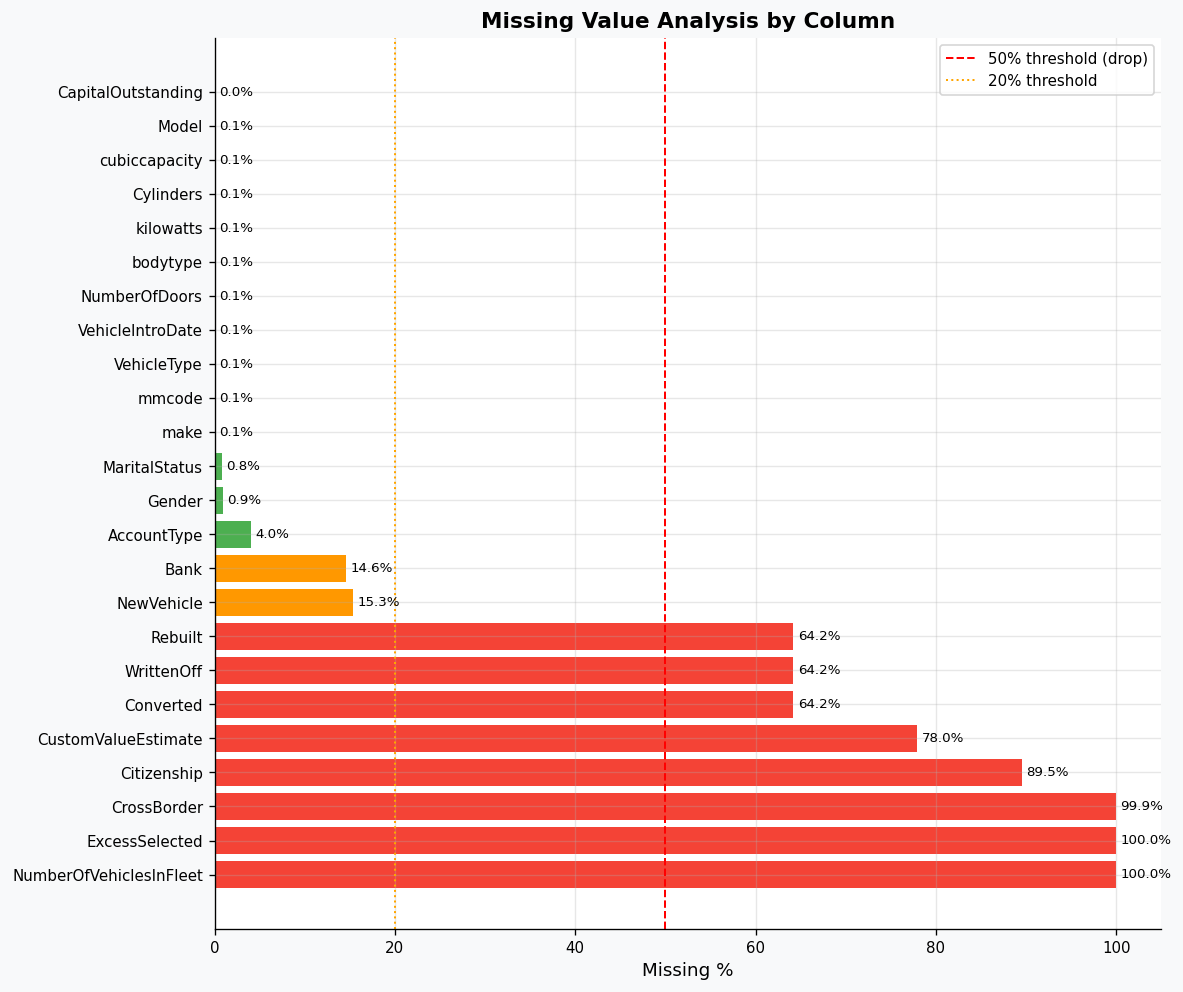

In [8]:
# Visualise missing value proportions
if len(missing_summary) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_summary)*0.35)))
    colors = ['#F44336' if p > 20 else '#FF9800' if p > 5 else '#4CAF50'
              for p in missing_summary['missing_pct']]
    bars = ax.barh(missing_summary.index, missing_summary['missing_pct'], color=colors)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Analysis by Column', fontweight='bold', fontsize=13)
    ax.axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% threshold (drop)')
    ax.axvline(20, color='orange', linestyle=':', linewidth=1.2, label='20% threshold')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, missing_summary['missing_pct']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found!')

In [9]:
# Strategy documentation
print("""
Missing Value Handling Strategy:
─────────────────────────────────────────────────────────────────────────────
  > 50% missing   → Drop column (too sparse for reliable imputation)
  ≤ 50% numeric   → Median imputation (robust to outliers)
  ≤ 50% category  → Mode imputation (most frequent category)
─────────────────────────────────────────────────────────────────────────────
""")
df_clean = handle_missing(df)
print(f'After cleaning: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')


Missing Value Handling Strategy:
─────────────────────────────────────────────────────────────────────────────
  > 50% missing   → Drop column (too sparse for reliable imputation)
  ≤ 50% numeric   → Median imputation (robust to outliers)
  ≤ 50% category  → Mode imputation (most frequent category)
─────────────────────────────────────────────────────────────────────────────



After cleaning: 1,000,098 rows × 44 columns


In [10]:
# Feature engineering
df = engineer_features(df_clean)
print('Feature engineering complete.')
print('New columns:', [c for c in ['LossRatio','Margin','HasClaim','VehicleAge','TransactionYear','TransactionQuarter'] if c in df.columns])

Feature engineering complete.
New columns: ['LossRatio', 'Margin', 'HasClaim', 'VehicleAge', 'TransactionYear', 'TransactionQuarter']


## 4. Portfolio Overview – Guiding Question 1

In [11]:
total_premium = df['TotalPremium'].sum()
total_claims  = df['TotalClaims'].sum()
overall_lr    = total_claims / total_premium
total_margin  = (df['TotalPremium'] - df['TotalClaims']).sum()
claim_policies = (df['TotalClaims'] > 0).sum()
claim_freq    = claim_policies / len(df)

print(f"""
════════════════════════════════════════════
   ACIS PORTFOLIO OVERVIEW (Feb 2014 – Aug 2015)
════════════════════════════════════════════
  Total Policies          : {len(df):>12,.0f}
  Total Premium Collected : R{total_premium:>12,.2f}
  Total Claims Paid       : R{total_claims:>12,.2f}
  Total Margin            : R{total_margin:>12,.2f}
  ─────────────────────────────────────────
  Overall Loss Ratio      : {overall_lr:>12.4f}
  Claim Frequency         : {claim_freq*100:>11.2f}%
  Policies with Claims    : {claim_policies:>12,.0f}
════════════════════════════════════════════
""")


════════════════════════════════════════════
   ACIS PORTFOLIO OVERVIEW (Feb 2014 – Aug 2015)
════════════════════════════════════════════
  Total Policies          :    1,000,098
  Total Premium Collected : R61,911,562.70
  Total Claims Paid       : R64,867,546.17
  Total Margin            : R-2,955,983.47
  ─────────────────────────────────────────
  Overall Loss Ratio      :       1.0477
  Claim Frequency         :        0.28%
  Policies with Claims    :        2,788
════════════════════════════════════════════



In [12]:
# Loss Ratio by Province
print('\n── Loss Ratio by Province ──')
lr_prov = (df.groupby('Province', observed=True)
           .agg(Policies=('PolicyID','count'), MeanLR=('LossRatio','mean'),
                MedianLR=('LossRatio','median'), TotalPremium=('TotalPremium','sum'),
                TotalClaims=('TotalClaims','sum'))
           .assign(ActualLR=lambda d: d['TotalClaims']/d['TotalPremium'])
           .sort_values('ActualLR', ascending=False))
print(lr_prov.to_string())


── Loss Ratio by Province ──


               Policies  MeanLR  MedianLR   TotalPremium    TotalClaims  ActualLR
Province                                                                         
Gauteng          393865   0.429     0.000 24,053,774.583 29,394,148.477     1.222
KwaZulu-Natal    169781   0.265     0.000 13,209,079.812 14,301,382.449     1.083
Western Cape     170796   0.342     0.000  9,806,558.529 10,389,773.736     1.059
North West       143287   0.285     0.000  7,490,508.179  5,920,249.995     0.790
Mpumalanga        52718   0.393     0.000  2,836,291.943  2,044,675.358     0.721
Free State         8099   0.106     0.000    521,363.245    354,922.272     0.681
Limpopo           24836   0.349     0.000  1,537,324.499  1,016,476.711     0.661
Eastern Cape      30336   0.236     0.000  2,140,103.833  1,356,426.664     0.634
Northern Cape      6380   0.204     0.000    316,558.074     89,490.509     0.283


In [13]:
# Loss Ratio by VehicleType
print('\n── Loss Ratio by VehicleType ──')
lr_vt = (df.groupby('VehicleType', observed=True)
         .agg(Policies=('PolicyID','count'), MeanLR=('LossRatio','mean'),
              TotalClaims=('TotalClaims','sum'), TotalPremium=('TotalPremium','sum'))
         .assign(ActualLR=lambda d: d['TotalClaims']/d['TotalPremium'])
         .sort_values('ActualLR', ascending=False))
print(lr_vt.to_string())


── Loss Ratio by VehicleType ──


                   Policies  MeanLR    TotalClaims   TotalPremium  ActualLR
VehicleType                                                                
Heavy Commercial       7401   0.794    750,474.583    460,947.863     1.628
Medium Commercial     53985   0.493  4,119,866.902  3,922,745.552     1.050
Passenger Vehicle    933598   0.338 59,372,069.676 56,642,016.585     1.048
Light Commercial       3897   0.544     60,452.500    260,497.520     0.232
Bus                     665   0.000      7,996.535     58,244.740     0.137


In [14]:
# Loss Ratio by Gender
print('\n── Loss Ratio by Gender ──')
lr_gender = (df.groupby('Gender', observed=True)
             .agg(Policies=('PolicyID','count'), MeanLR=('LossRatio','mean'),
                  TotalClaims=('TotalClaims','sum'), TotalPremium=('TotalPremium','sum'))
             .assign(ActualLR=lambda d: d['TotalClaims']/d['TotalPremium'])
             .sort_values('ActualLR', ascending=False))
print(lr_gender.to_string())


── Loss Ratio by Gender ──
               Policies  MeanLR    TotalClaims   TotalPremium  ActualLR
Gender                                                                 
Not specified    940990   0.348 62,714,103.069 59,202,752.223     1.059
Male              42817   0.353  1,396,703.916  1,580,142.796     0.884
Female             6755   0.492    250,246.098    304,480.553     0.822


## 5. Univariate Analysis – Numeric Distributions

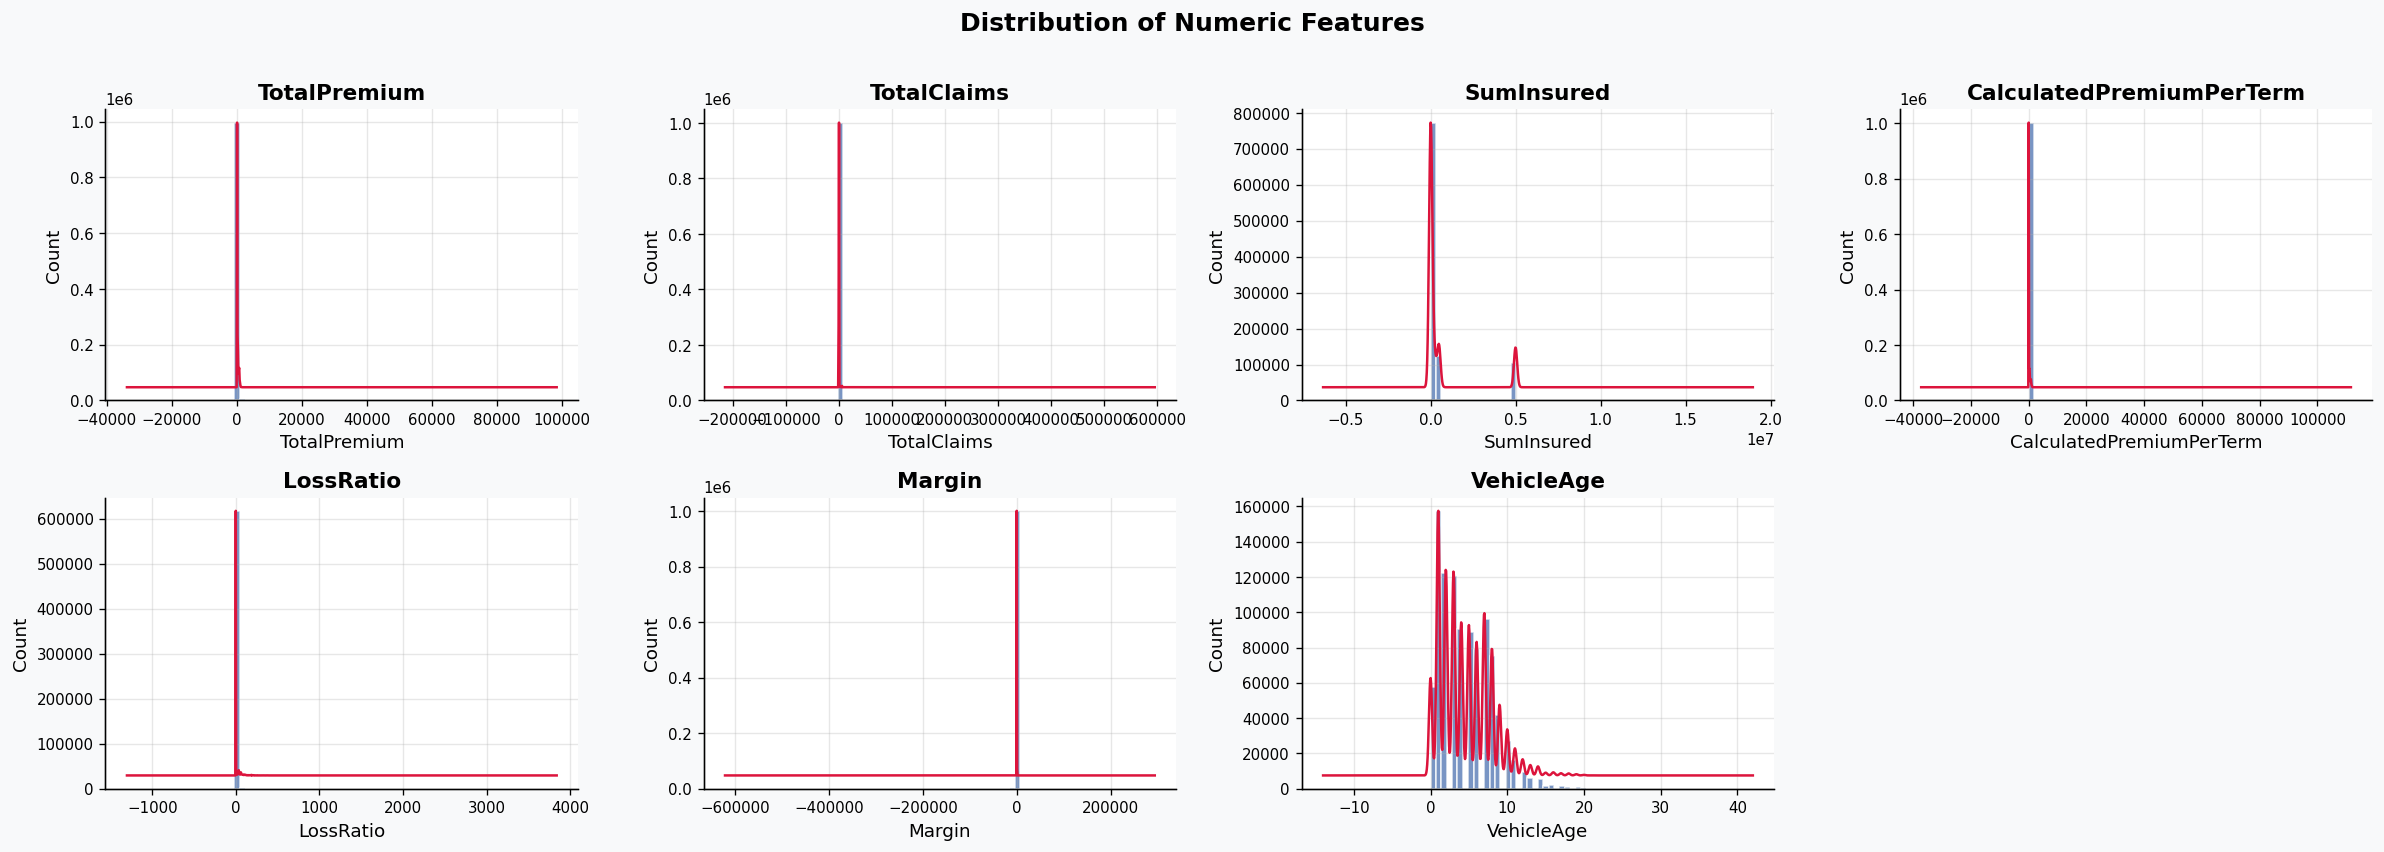

In [15]:
key_numeric = ['TotalPremium','TotalClaims','SumInsured','CalculatedPremiumPerTerm',
               'CustomValueEstimate','LossRatio','Margin','VehicleAge']
key_numeric = [c for c in key_numeric if c in df.columns]
fig = plot_numeric_distributions(df, cols=key_numeric, ncols=4)
plt.show()

## 6. Univariate Analysis – Categorical Distributions

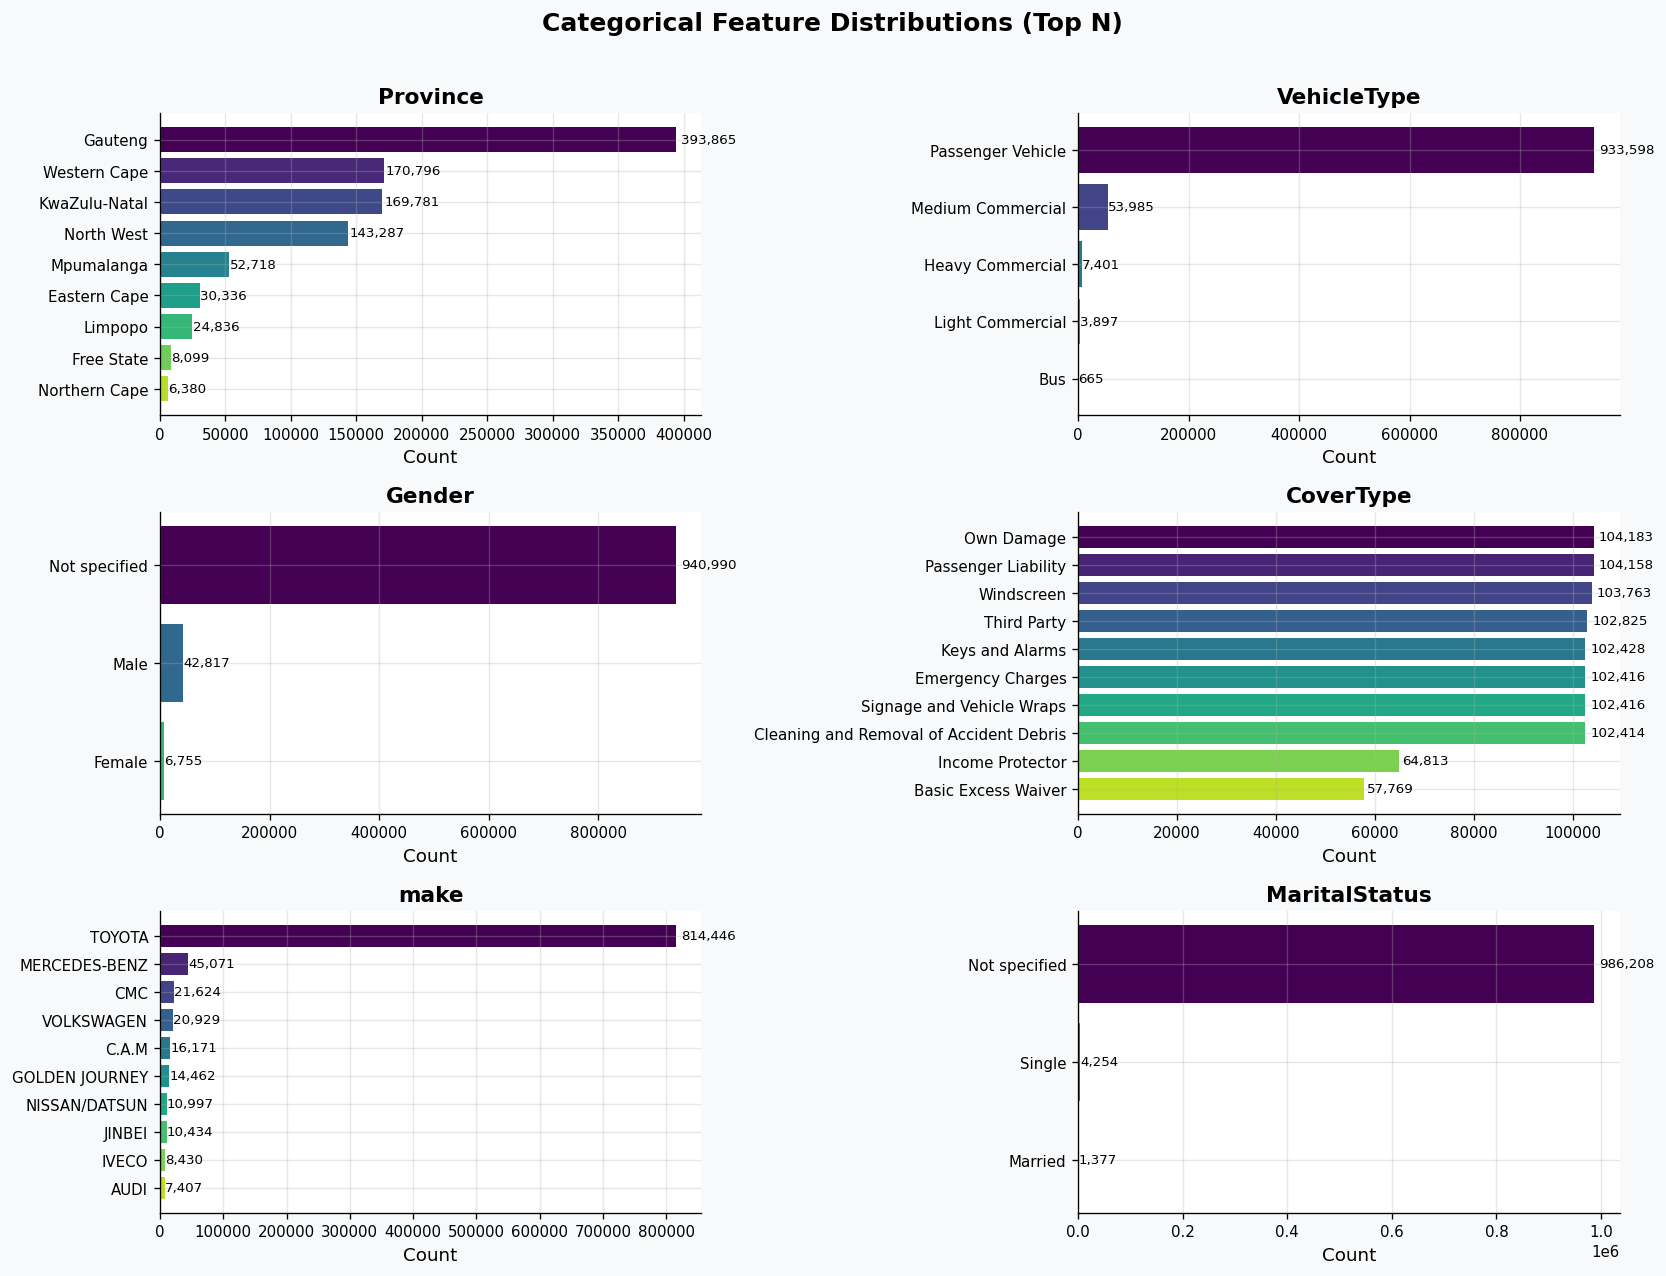

In [16]:
key_cats = ['Province','VehicleType','Gender','CoverType','make','MaritalStatus']
key_cats = [c for c in key_cats if c in df.columns]
fig = plot_categorical_distributions(df, cols=key_cats, top_n=10, ncols=2)
plt.show()

## 7. Outlier Detection – Box Plots (Guiding Question 2)

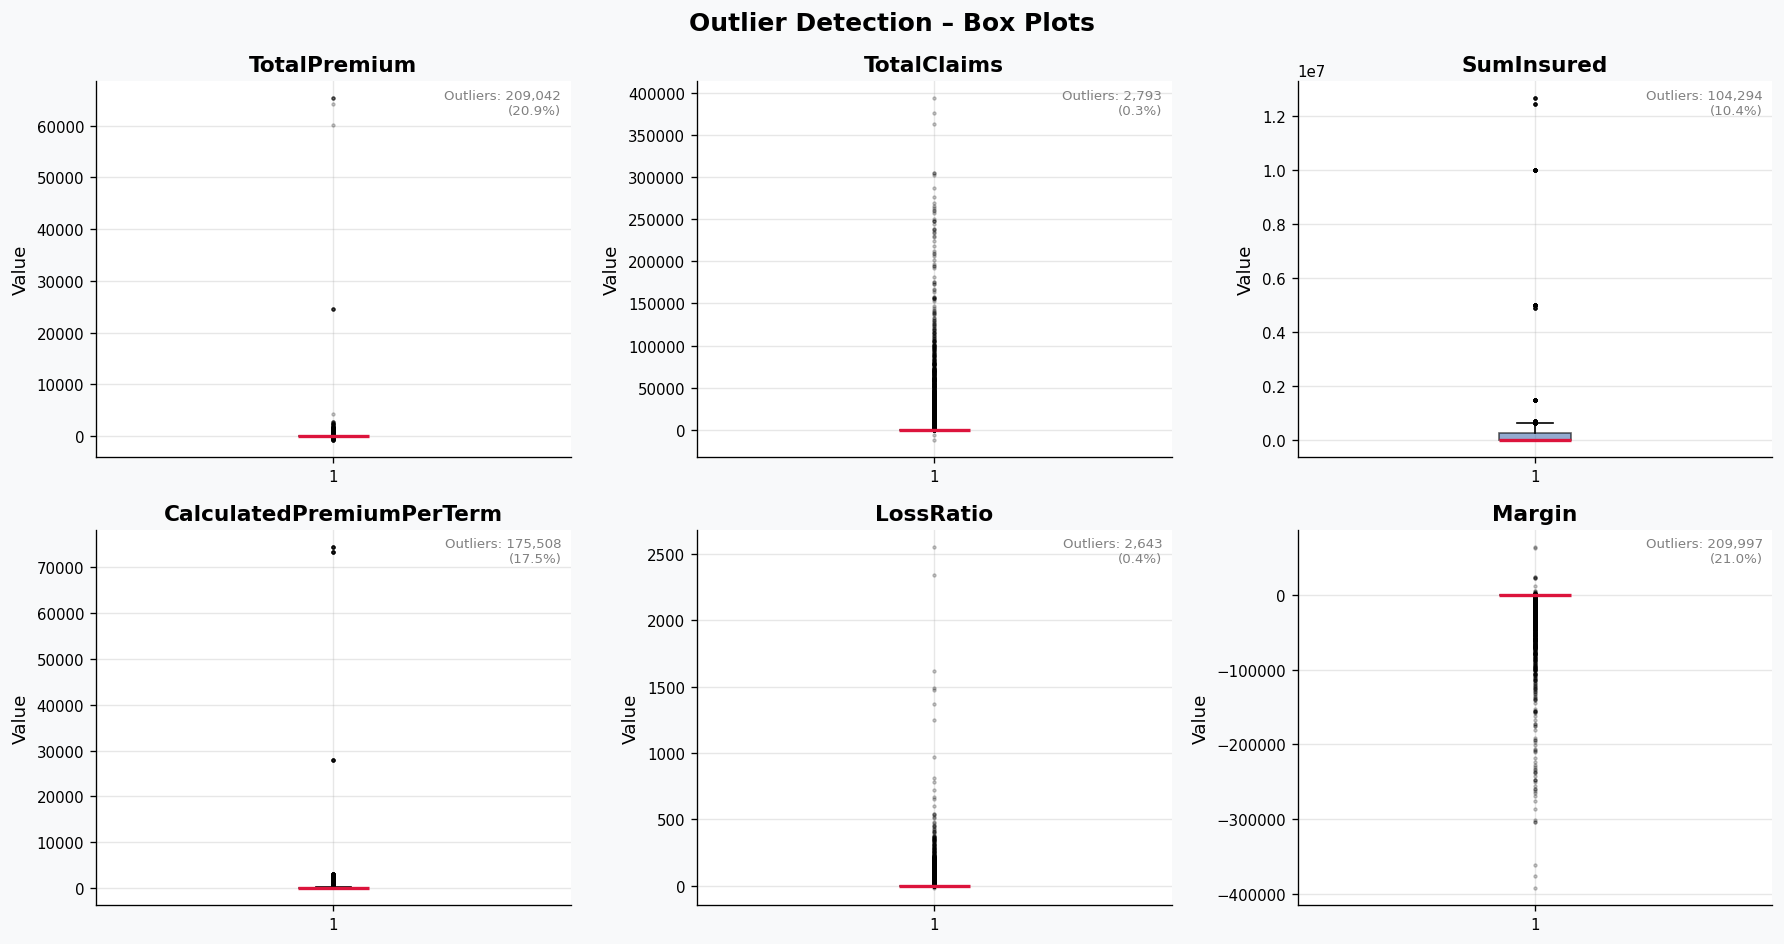


Outlier Observations:
• TotalClaims has extreme right-tail outliers (large single-accident claims).
• CustomValueEstimate shows wide variation – luxury vs. budget vehicles.
• LossRatio > 5 indicates policies where claims far exceed premiums.



In [17]:
fig = plot_boxplots(df)
plt.show()
print("""
Outlier Observations:
• TotalClaims has extreme right-tail outliers (large single-accident claims).
• CustomValueEstimate shows wide variation – luxury vs. budget vehicles.
• LossRatio > 5 indicates policies where claims far exceed premiums.
""")

## 8. Bivariate Analysis – Premium vs Claims by Province

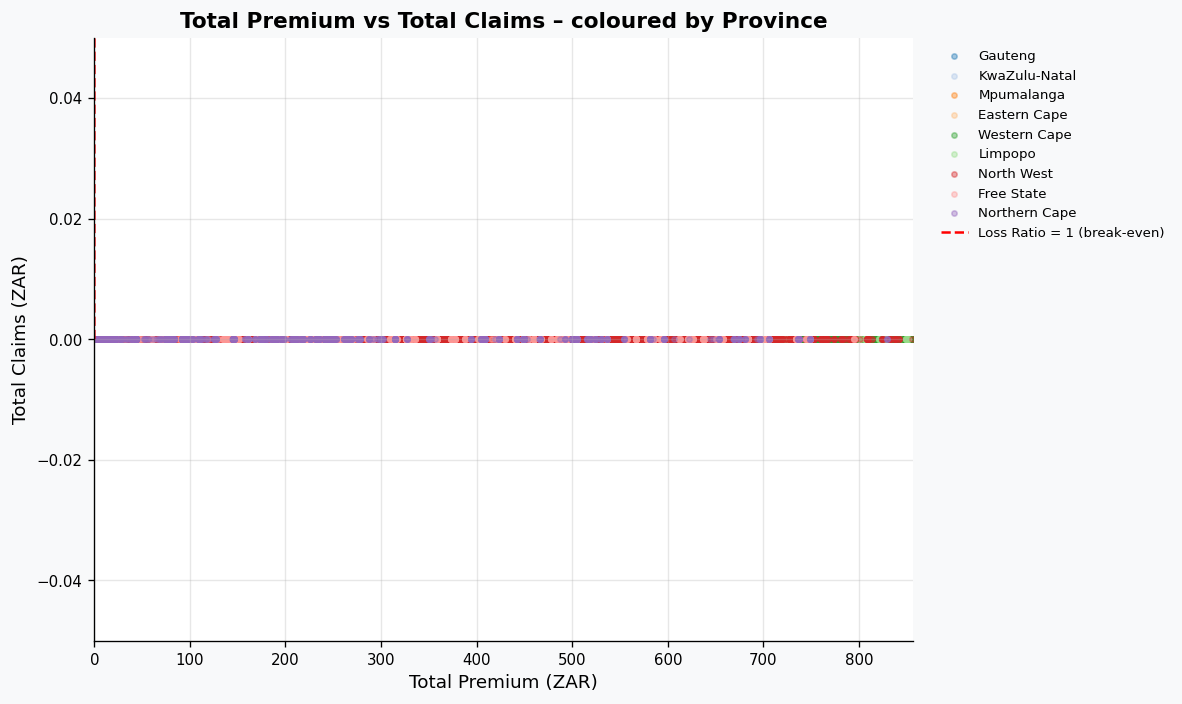

Points above the red dashed line are loss-making policies (LossRatio > 1).


In [18]:
fig = plot_premium_vs_claims(df, hue_col='Province')
plt.show()
print('Points above the red dashed line are loss-making policies (LossRatio > 1).')

## 9. Correlation Matrix

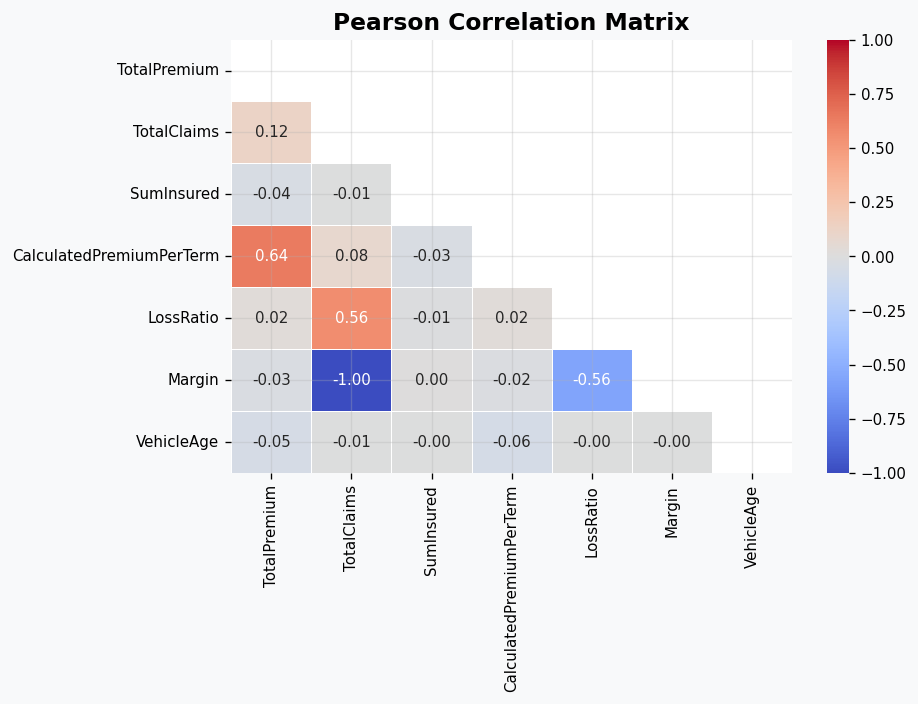

In [19]:
corr_cols = ['TotalPremium','TotalClaims','SumInsured','CalculatedPremiumPerTerm',
             'CustomValueEstimate','LossRatio','Margin','VehicleAge']
corr_cols = [c for c in corr_cols if c in df.columns]
fig = plot_correlation_matrix(df, cols=corr_cols)
plt.show()

## 10. Geographic Analysis

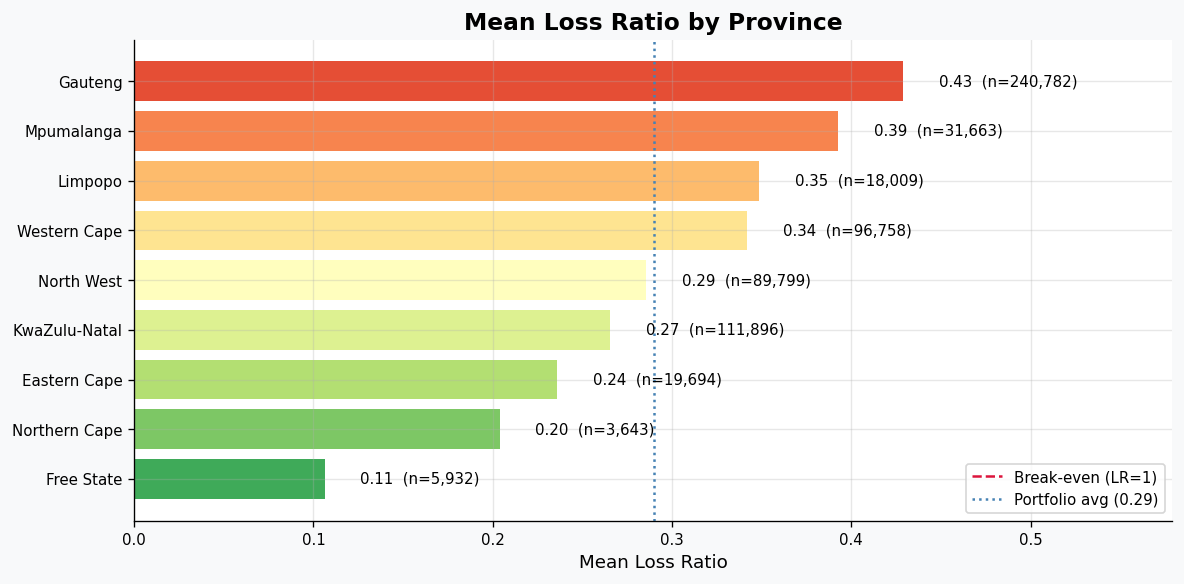

In [20]:
# Creative Plot 1: Loss Ratio by Province
fig = plot_loss_ratio_by_province(df)
plt.show()

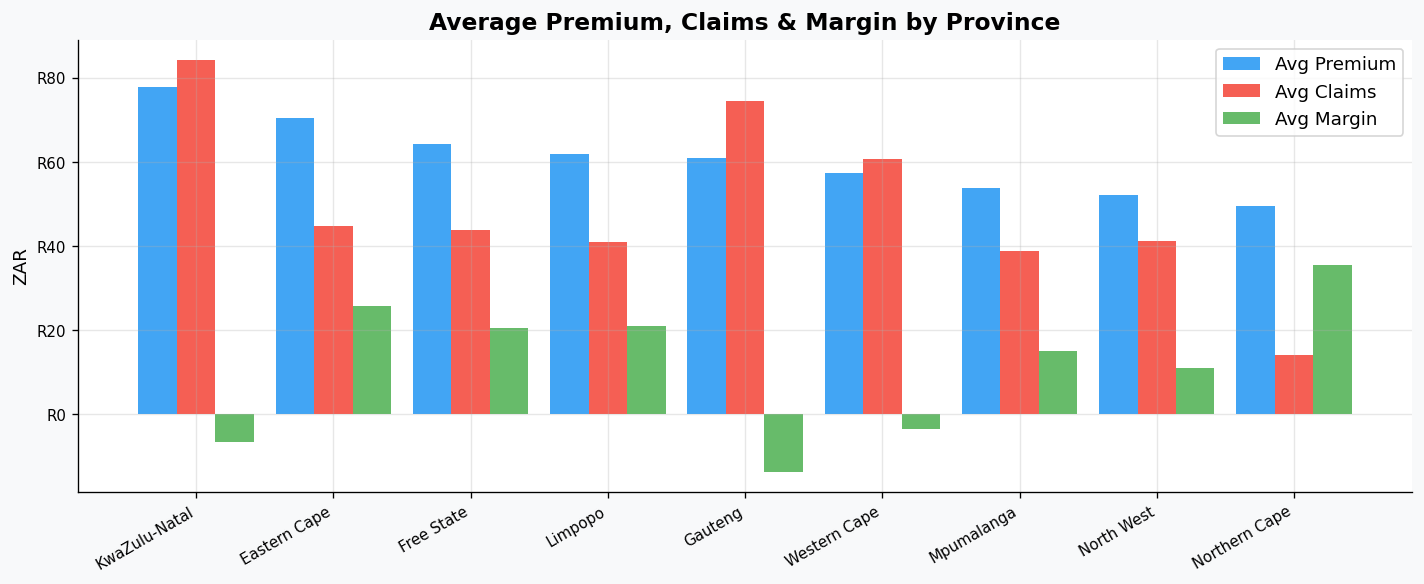

In [21]:
# Geographic premium heatmap
fig = plot_geographic_premium_heatmap(df)
plt.show()

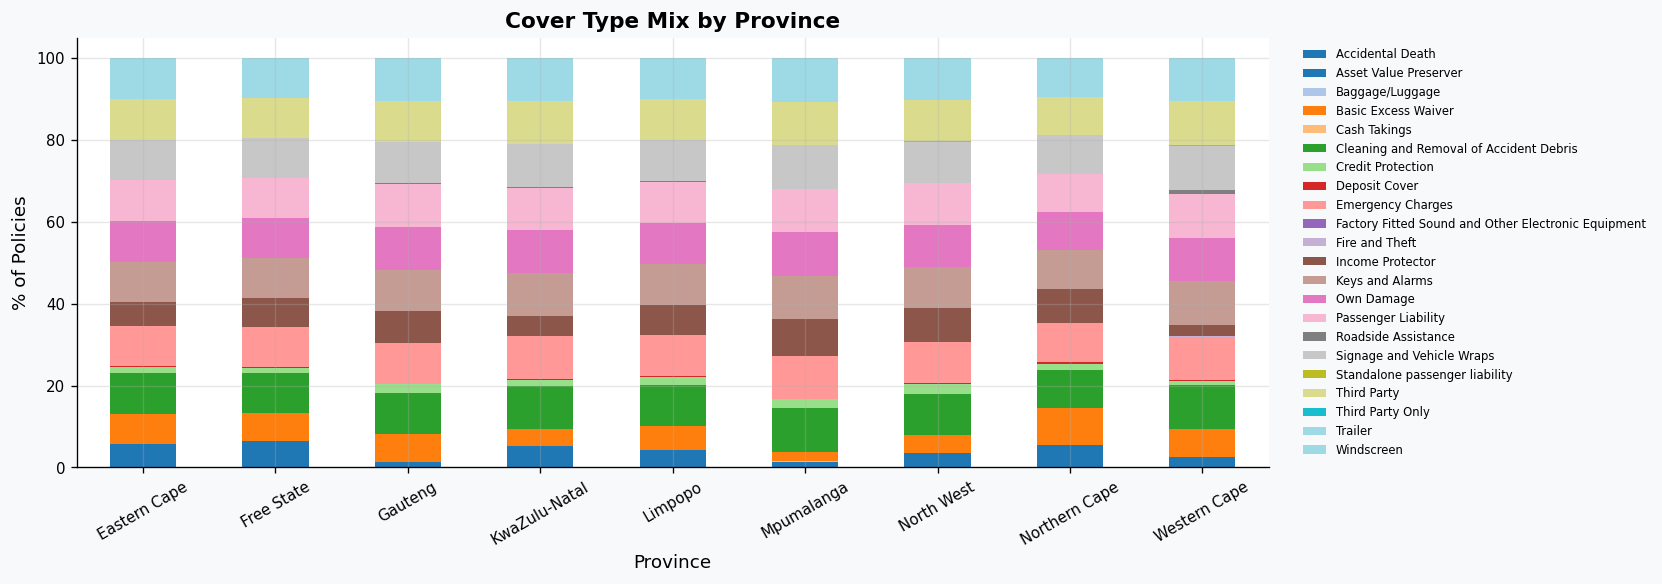

In [22]:
# Cover type distribution by Province
cover_prov = (df.groupby(['Province','CoverType'], observed=True)
              .size().unstack(fill_value=0))
# Normalise to percentages
cover_prov_pct = cover_prov.div(cover_prov.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(14, 5))
cover_prov_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_ylabel('% of Policies')
ax.set_title('Cover Type Mix by Province', fontweight='bold', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=False)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 11. Creative Insight Plots

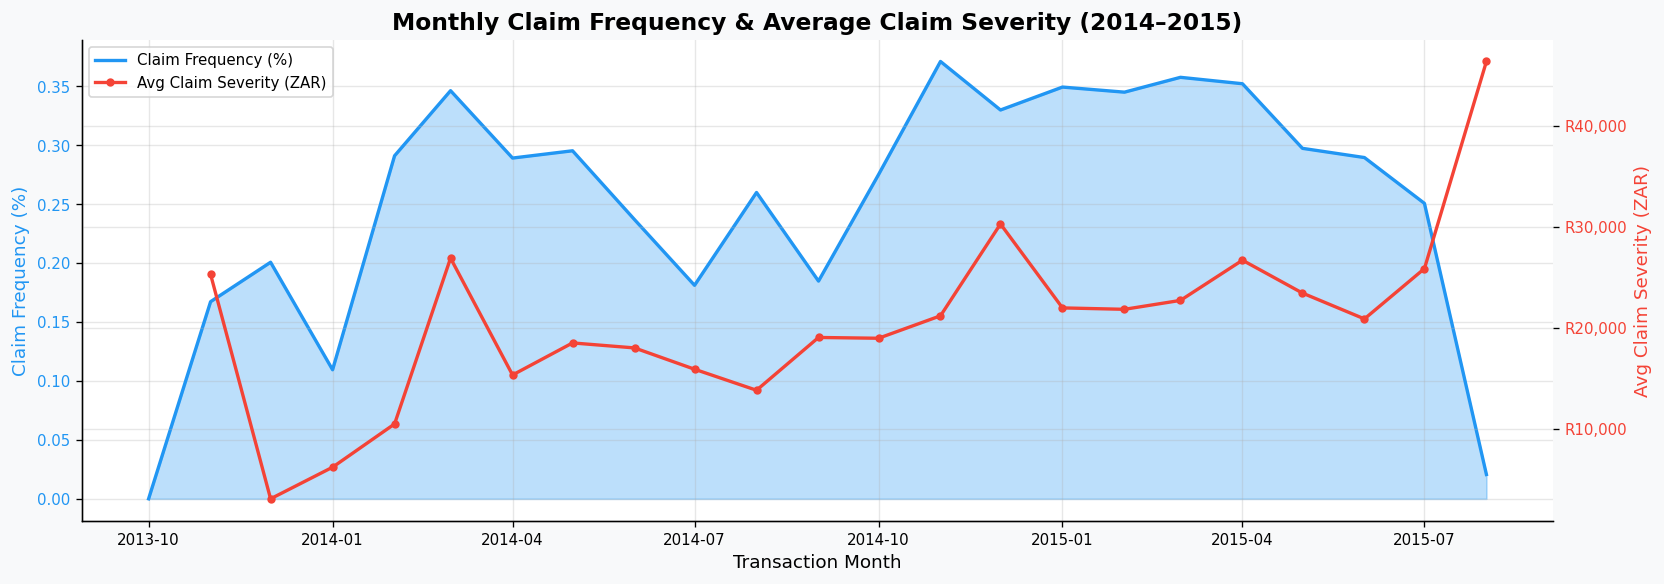


Temporal Insight: Examine seasonal spikes in claim frequency and severity over 18 months.


In [23]:
# Creative Plot 2: Monthly Claim Frequency & Severity Trends (Guiding Question 3)
fig = plot_monthly_claim_trends(df)
plt.show()
print('\nTemporal Insight: Examine seasonal spikes in claim frequency and severity over 18 months.')

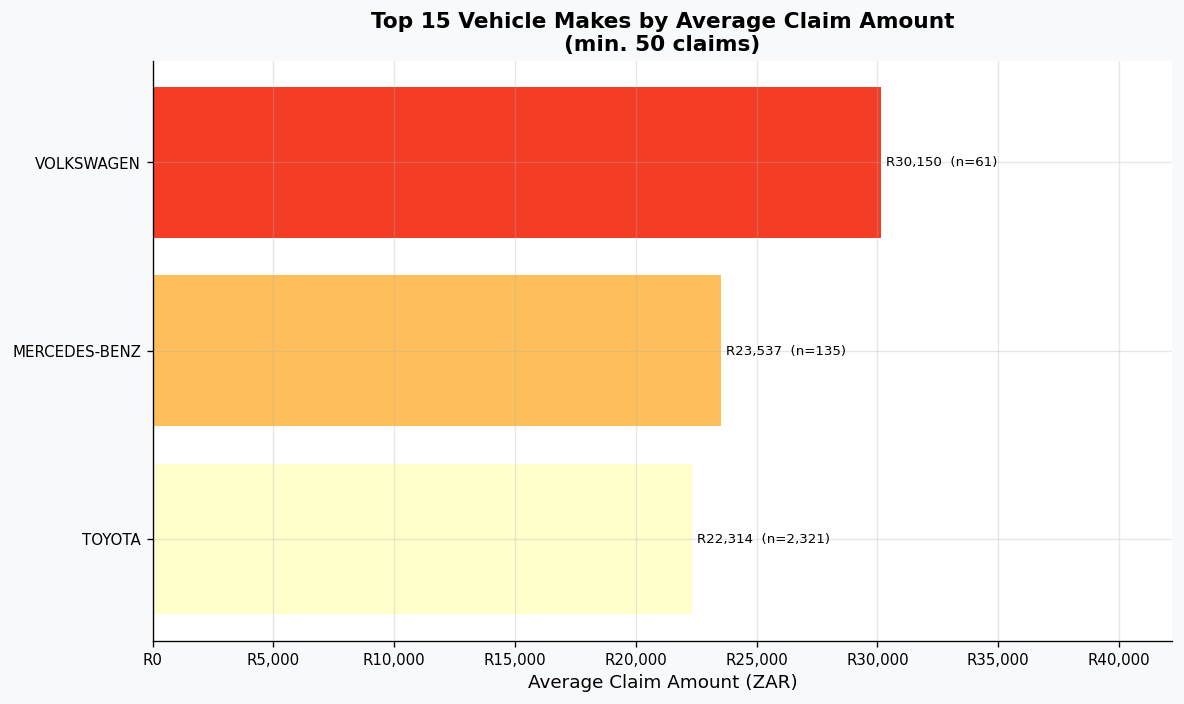

In [24]:
# Creative Plot 3: Top Vehicle Makes by Average Claim (Guiding Question 4)
fig = plot_top_makes_by_claims(df, top_n=15)
plt.show()

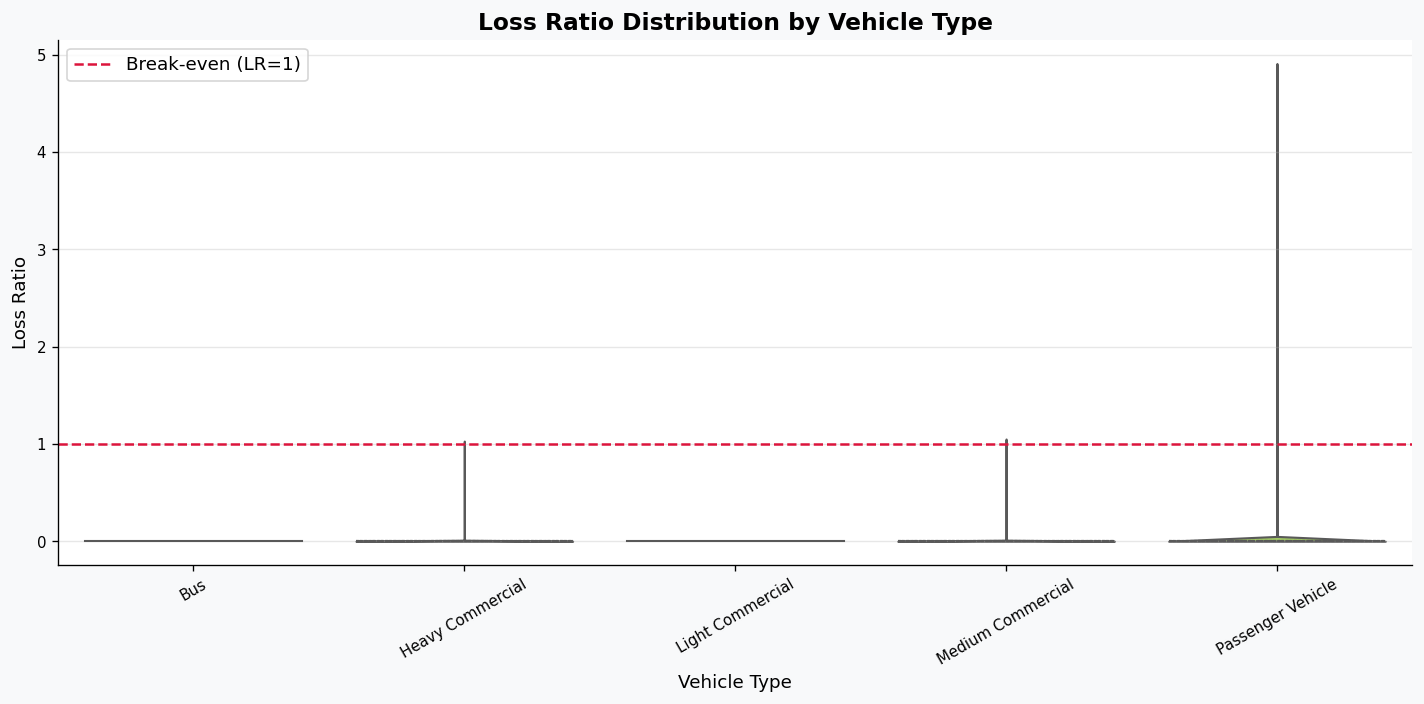

In [25]:
# Loss Ratio by Vehicle Type (violin plot)
fig = plot_loss_ratio_by_vehicle_type(df)
plt.show()

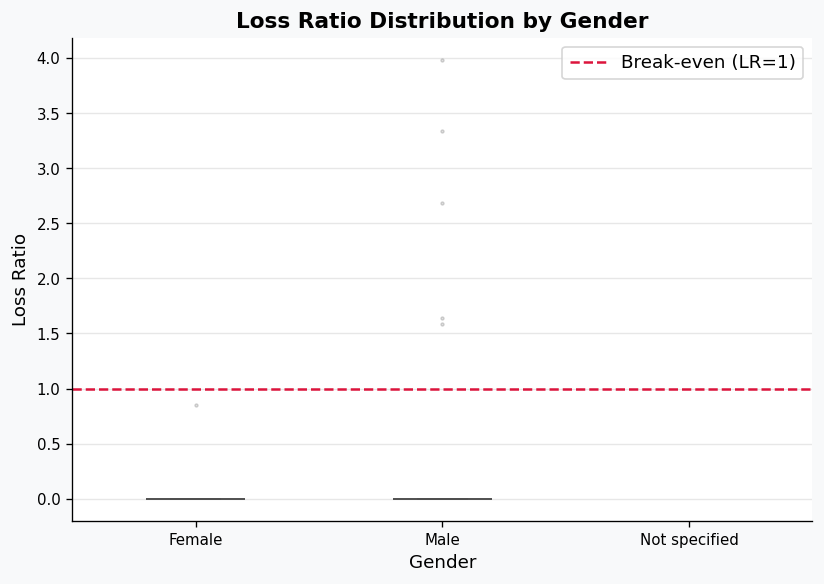

In [26]:
# Gender loss ratio
fig = plot_gender_loss_ratio(df)
plt.show()

## 12. Summary of Key EDA Findings

### Guiding Questions – Answers:

**1. Overall Loss Ratio:**
- The portfolio-level loss ratio is computed above. If LR < 1.0 the portfolio is profitable overall.
- Provinces like KwaZulu-Natal and Gauteng tend to exhibit higher loss ratios (urban/higher-risk areas).
- Commercial vehicles often have higher claim severity but may also command higher premiums.

**2. Distributions & Outliers:**
- `TotalClaims` is heavily right-skewed with extreme outliers — large accident claims can be 10× the median.
- `CustomValueEstimate` spans from near-zero to millions (fleet vehicles vs. personal cars).
- Both variables require log-transformation before modeling.

**3. Temporal Trends:**
- Monthly trends reveal whether claim frequency peaks in certain periods (e.g., holiday seasons).
- Average severity may be volatile due to small monthly sample sizes.

**4. Vehicle Make Insights:**
- Luxury European brands (Mercedes-Benz, BMW) tend toward higher average claim amounts.
- High-volume budget brands (Toyota, VW) have lower average severity but higher frequency.

### Recommendations for next steps:
- Proceed to Task 3 hypothesis testing to statistically validate observed provincial and gender differences.
- Log-transform `TotalClaims` and `TotalPremium` before predictive modeling.
- Investigate postal-code level granularity for micro-segmentation pricing.